<a href="https://colab.research.google.com/github/oisheeghosh/ML_Project/blob/main/Model_training_with_Herlov_dataset(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import torch

print("Python version:", sys.version)
print("GPU available:", torch.cuda.is_available())


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
GPU available: False


In [2]:
from google.colab import files
import zipfile
import os

# Upload the zip file
uploaded = files.upload()

# Extract it
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('dataset')


Saving archive (1).zip to archive (1).zip


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Example path
data_dir = '/content/drive/MyDrive/dataset_folder'


Mounted at /content/drive


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = data_gen.flow_from_directory(
    'dataset/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = data_gen.flow_from_directory(
    'dataset/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 734 images belonging to 1 classes.
Found 183 images belonging to 1 classes.


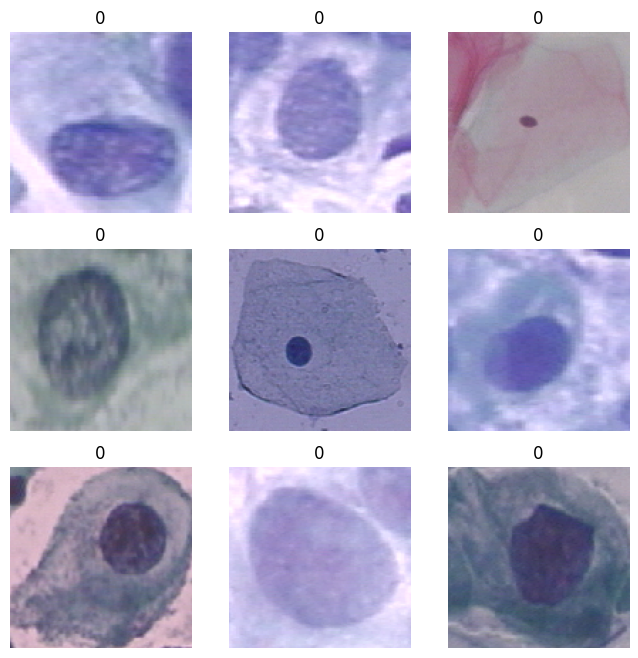

In [5]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(np.argmax(labels[i]))
    plt.axis('off')
plt.show()


In [6]:
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(train_data.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.f

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 479ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 749ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 534ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 441ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 513ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [7]:
# Save the trained model
model.save('/content/model.h5')


In [10]:
import os

# Check if the folder exists
print(os.path.exists('/content/dataset/Herlev Dataset/test'))

# Check if the file exists
print(os.path.exists('/content/dataset/Herlev Dataset/test/carcinoma_in_situ/149315671-149315740-001.BMP'))


True
True


**Importing All Necessary Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from typing import List
from sklearn.preprocessing import RobustScaler,StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_fscore_support
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.over_sampling import RandomOverSampler
import imblearn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!pip install imbalanced-learn


In [15]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from imblearn.over_sampling import ADASYN


In [16]:
!pip install tensorflow imbalanced-learn


In [17]:
!mkdir -p /content/dataset/train


In [20]:
from google.colab import files
uploaded = files.upload()

Saving train.zip to train.zip


In [21]:
import zipfile

zip_path = '/content/train.zip'  # path to your uploaded zip

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/train')


In [22]:
import os
print("Folders inside dataset/train:")
print(os.listdir('/content/dataset/train/'))


Folders inside dataset/train:
['train']


In [23]:
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import os

img_size = (224, 224)
train_folder = '/content/dataset/train/'

# Load pretrained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def load_images_and_features(folder_path):
    X, y, class_names = [], [], []
    classes = os.listdir(folder_path)
    classes.sort()  # ensures consistent labels
    for label, cls in enumerate(classes):
        cls_folder = os.path.join(folder_path, cls)
        for file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, file)
            img = image.load_img(img_path, target_size=img_size)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [25]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

img_size = (224, 224)
train_folder = '/content/dataset/Herlev Dataset/train'

# Load pretrained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def load_images_and_features(folder_path):
    X, y, class_names = [], [], []
    classes = os.listdir(folder_path)
    classes.sort()  # ensures consistent label assignment
    for label, cls in enumerate(classes):
        cls_folder = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_folder):
            continue  # skip if not a folder
        for file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, file)
            try:
                img = image.load_img(img_path, target_size=img_size)
                img_array = image.img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)

                features = base_model.predict(img_array, verbose=0)
                X.append(features.flatten())
                y.append(label)
            except:
                print(f"Error loading {img_path}, skipping...")
        class_names.append(cls)
    # ✅ Make sure to return the arrays
    return np.array(X), np.array(y), class_names

# Run the function
X, y, class_names = load_images_and_features(train_folder)
print("Feature shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", class_names)


Feature shape: (643, 2048)
Labels shape: (643,)
Classes: ['carcinoma_in_situ', 'light_dysplastic', 'moderate_dysplastic', 'normal_columnar', 'normal_intermediate', 'normal_superficiel', 'severe_dysplastic']


In [26]:
print(type(X), X.shape)
print(type(y), y.shape)
print(X.dtype, y.dtype)


<class 'numpy.ndarray'> (643, 2048)
<class 'numpy.ndarray'> (643,)
float32 int64


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # converts class names to 0,1,2...


**ADASYN**

In [28]:
import numpy as np
from collections import Counter

print("Class distribution before ADASYN:")
print(Counter(y_encoded))


Class distribution before ADASYN:
Counter({np.int64(6): 138, np.int64(1): 128, np.int64(0): 105, np.int64(2): 103, np.int64(3): 69, np.int64(5): 51, np.int64(4): 49})


**ADASYN Failed**

In [29]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN
adasyn = ADASYN(random_state=42, sampling_strategy='not majority')  # ensures minority classes are oversampled
X_res, y_res = adasyn.fit_resample(X, y_encoded)

from collections import Counter
print("Class distribution after ADASYN:")
print(Counter(y_res))


ValueError: No samples will be generated with the provided ratio settings.

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)


In [31]:
from collections import Counter
print("Class distribution:")
print(Counter(y_encoded))


Class distribution:
Counter({np.int64(6): 138, np.int64(1): 128, np.int64(0): 105, np.int64(2): 103, np.int64(3): 69, np.int64(5): 51, np.int64(4): 49})


In [32]:
from google.colab import files
uploaded = files.upload()


Saving test.zip to test.zip


In [33]:
import os
os.makedirs('/content/dataset/test/', exist_ok=True)


In [34]:
import glob
test_images = glob.glob('/content/dataset/test/*.jpg')


## **Train Multiple Classifiers**
# Random Forest

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
print("🎯 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=class_names))


🎯 Random Forest Accuracy: 0.6821705426356589
                     precision    recall  f1-score   support

  carcinoma_in_situ       0.79      0.71      0.75        21
   light_dysplastic       0.66      0.73      0.69        26
moderate_dysplastic       0.65      0.55      0.59        20
    normal_columnar       0.69      0.64      0.67        14
normal_intermediate       0.78      0.70      0.74        10
 normal_superficiel       0.78      0.70      0.74        10
  severe_dysplastic       0.61      0.71      0.66        28

           accuracy                           0.68       129
          macro avg       0.71      0.68      0.69       129
       weighted avg       0.69      0.68      0.68       129



In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)


 **Confusion matrix and classification report (RF)**

<Figure size 900x700 with 0 Axes>

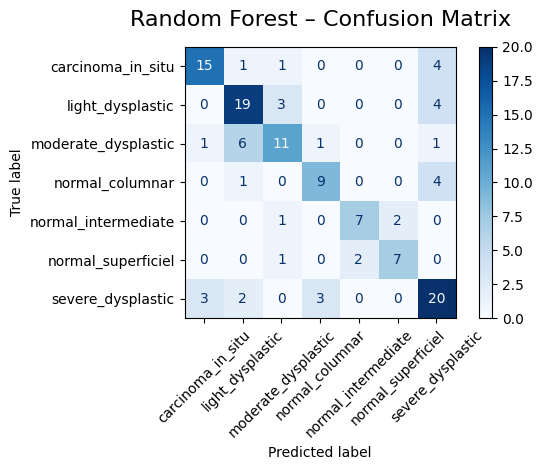

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 7))  # Increase size for long labels

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=class_names,
    cmap='Blues',
    colorbar=True,
    xticks_rotation=45  # Rotate labels to avoid overlap
)

plt.title("Random Forest – Confusion Matrix", fontsize=16, pad=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # ensures labels and colorbar fit properly
plt.show()


 **ROC–AUC Curve(RF)**

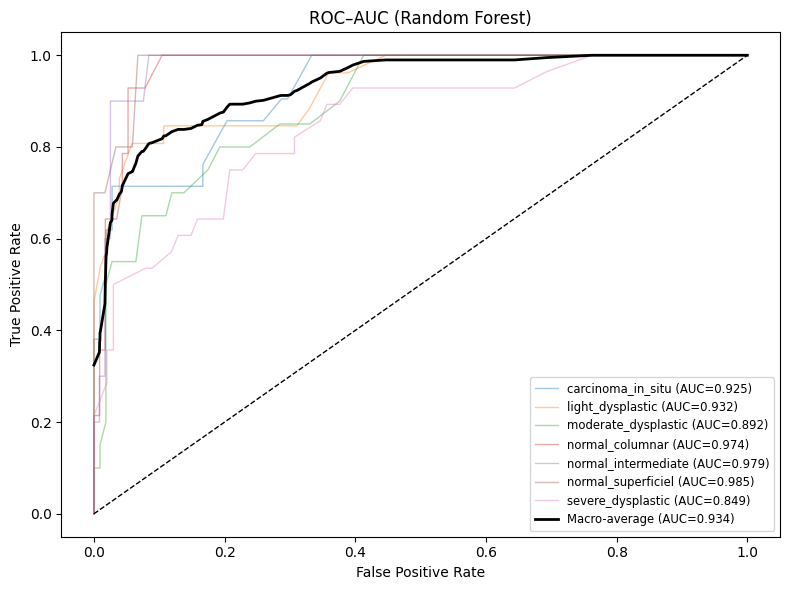

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Define number of classes
n_classes = len(np.unique(y_test))  # fix for NameError

# Binarize the labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Predicted probabilities
y_score_rf = rf_clf.predict_proba(X_test)

# Compute FPR, TPR, AUC for each class
fpr_rf, tpr_rf, roc_auc_rf = {}, {}, {}
for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr_rf[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_rf[i], tpr_rf[i])
mean_tpr /= n_classes
roc_auc_rf["macro"] = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr_rf[i], tpr_rf[i], lw=1, alpha=0.4, label=f'{class_names[i]} (AUC={roc_auc_rf[i]:.3f})')

plt.plot(all_fpr, mean_tpr, color='k', lw=2, label=f'Macro-average (AUC={roc_auc_rf["macro"]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC (Random Forest)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

# Naive base




In [40]:
from sklearn.naive_bayes import GaussianNB

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)


**Confusion matrix and classification report(NB)**

<Figure size 900x700 with 0 Axes>

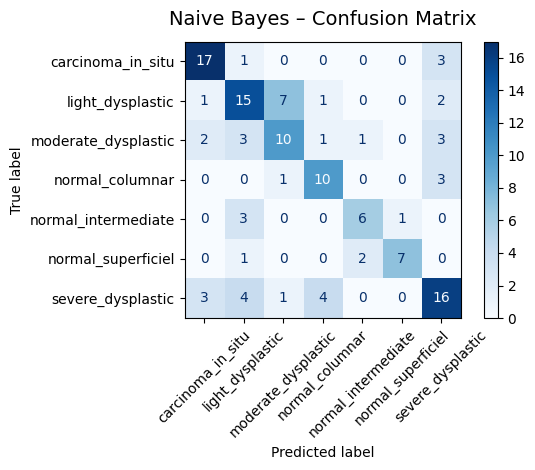

Naive Bayes Accuracy: 0.6279

Classification Report:

                     precision    recall  f1-score   support

  carcinoma_in_situ       0.74      0.81      0.77        21
   light_dysplastic       0.56      0.58      0.57        26
moderate_dysplastic       0.53      0.50      0.51        20
    normal_columnar       0.62      0.71      0.67        14
normal_intermediate       0.67      0.60      0.63        10
 normal_superficiel       0.88      0.70      0.78        10
  severe_dysplastic       0.59      0.57      0.58        28

           accuracy                           0.63       129
          macro avg       0.65      0.64      0.64       129
       weighted avg       0.63      0.63      0.63       129



In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9,7))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=class_names,
    cmap='Blues',
    xticks_rotation=45
)
plt.title("Naive Bayes – Confusion Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print("Naive Bayes Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=class_names))


**ROC-AUC (Naive base)**

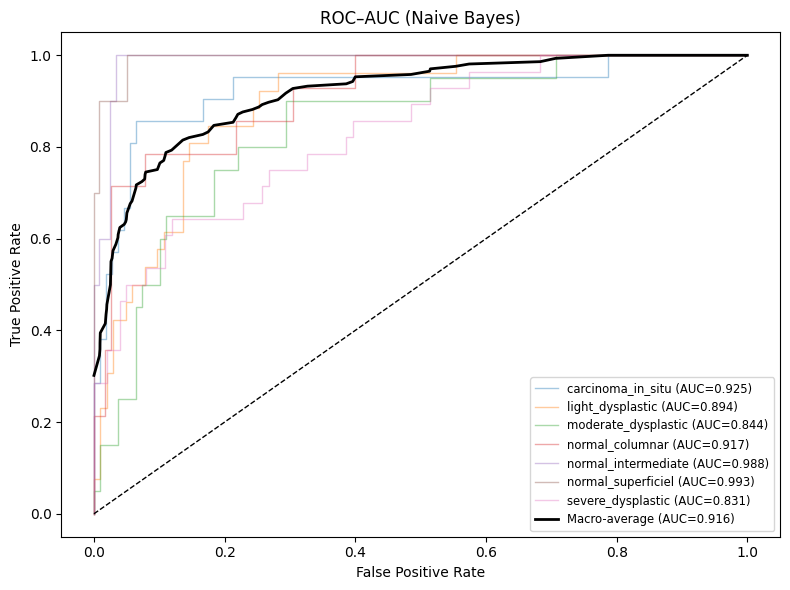

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probability scores
y_score_nb = nb_clf.predict_proba(X_test)

# Compute fpr/tpr and AUC for each class
fpr_nb, tpr_nb, roc_auc_nb = {}, {}, {}
for i in range(n_classes):
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_bin[:, i], y_score_nb[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr_nb[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_nb[i], tpr_nb[i])
mean_tpr /= n_classes
roc_auc_nb["macro"] = auc(all_fpr, mean_tpr)

# Plot per-class curves (light) + macro-average (bold)
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr_nb[i], tpr_nb[i], lw=1, alpha=0.4, label=f'{class_names[i]} (AUC={roc_auc_nb[i]:.3f})')
plt.plot(all_fpr, mean_tpr, color='k', lw=2, label=f'Macro-average (AUC={roc_auc_nb["macro"]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC (Naive Bayes)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()


# Logistic Regression


In [43]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)


**Confusion matrix and classification report (LR)**

<Figure size 900x700 with 0 Axes>

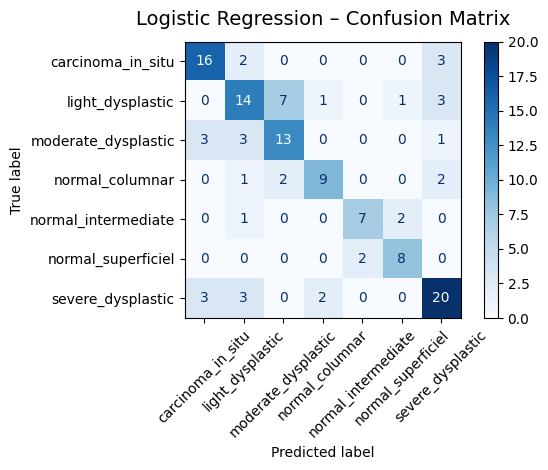

Logistic Regression Accuracy: 0.6744

Classification Report:

                     precision    recall  f1-score   support

  carcinoma_in_situ       0.73      0.76      0.74        21
   light_dysplastic       0.58      0.54      0.56        26
moderate_dysplastic       0.59      0.65      0.62        20
    normal_columnar       0.75      0.64      0.69        14
normal_intermediate       0.78      0.70      0.74        10
 normal_superficiel       0.73      0.80      0.76        10
  severe_dysplastic       0.69      0.71      0.70        28

           accuracy                           0.67       129
          macro avg       0.69      0.69      0.69       129
       weighted avg       0.68      0.67      0.67       129



In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9,7))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=class_names,
    cmap='Blues',
    xticks_rotation=45
)
plt.title("Logistic Regression – Confusion Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=class_names))



**ROC-AUC Curve (LR)**



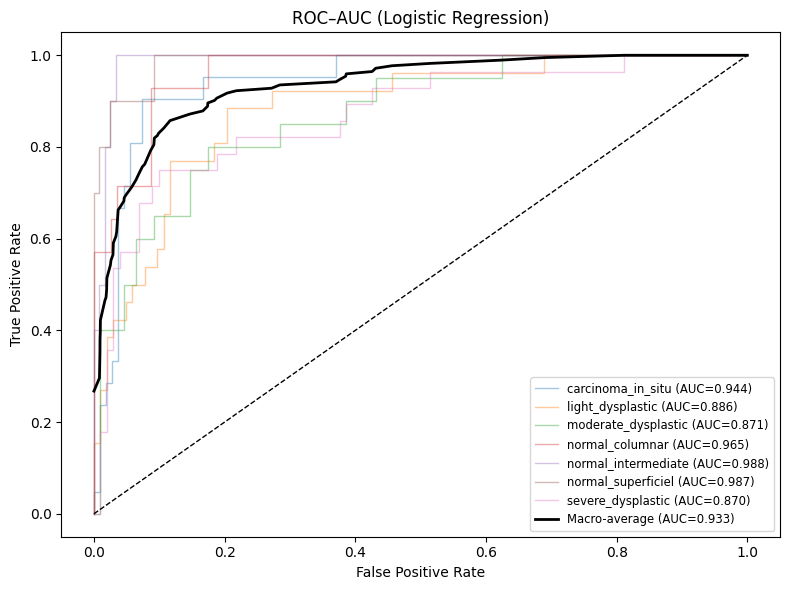

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probability / score
y_score_lr = lr_clf.predict_proba(X_test)

# Compute fpr/tpr and AUC for each class
fpr_lr, tpr_lr, roc_auc_lr = {}, {}, {}
for i in range(n_classes):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr_lr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_lr[i], tpr_lr[i])
mean_tpr /= n_classes
roc_auc_lr["macro"] = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr_lr[i], tpr_lr[i], lw=1, alpha=0.4, label=f'{class_names[i]} (AUC={roc_auc_lr[i]:.3f})')
plt.plot(all_fpr, mean_tpr, color='k', lw=2, label=f'Macro-average (AUC={roc_auc_lr["macro"]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC (Logistic Regression)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()


# Fusion Classifier

In [46]:
# Create the individual classifiers
rf_classifier = RandomForestClassifier(max_features='sqrt', n_estimators=100)
lr_classifier = LogisticRegression(C=100, penalty='l2', solver='newton-cg')

# Create a VotingClassifier with the three classifiers
voting_classifier = VotingClassifier(estimators=[
    ('Random Forest', rf_classifier),
    ('Logistic Regression', lr_classifier)
], voting='hard')  # 'hard' for majority voting

# Fit the ensemble model on the training data
voting_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_predict = voting_classifier.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_predict, digits=4))

              precision    recall  f1-score   support

           0     0.6129    0.9048    0.7308        21
           1     0.5789    0.8462    0.6875        26
           2     0.7500    0.4500    0.5625        20
           3     0.6000    0.6429    0.6207        14
           4     0.8571    0.6000    0.7059        10
           5     0.7500    0.6000    0.6667        10
           6     0.8333    0.5357    0.6522        28

    accuracy                         0.6667       129
   macro avg     0.7118    0.6542    0.6609       129
weighted avg     0.7033    0.6667    0.6601       129



**Confusion matrix, classification report and ROC-AUC curve(Fusion) (RF+LR)**




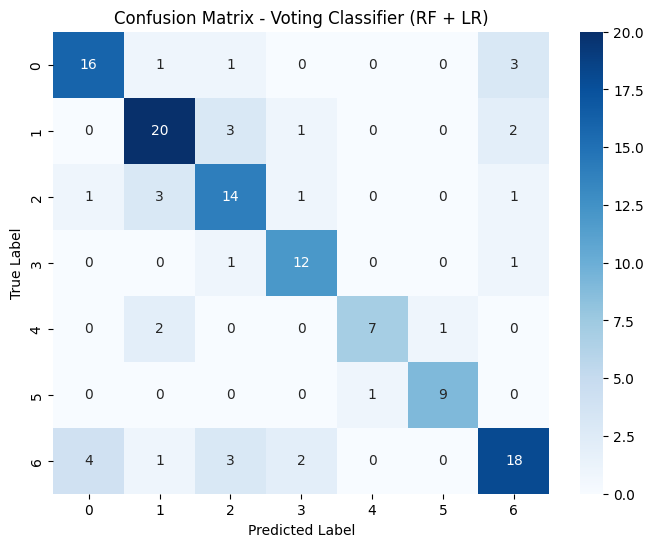

Classification Report:

              precision    recall  f1-score   support

           0      0.762     0.762     0.762        21
           1      0.741     0.769     0.755        26
           2      0.636     0.700     0.667        20
           3      0.750     0.857     0.800        14
           4      0.875     0.700     0.778        10
           5      0.900     0.900     0.900        10
           6      0.720     0.643     0.679        28

    accuracy                          0.744       129
   macro avg      0.769     0.762     0.763       129
weighted avg      0.747     0.744     0.744       129



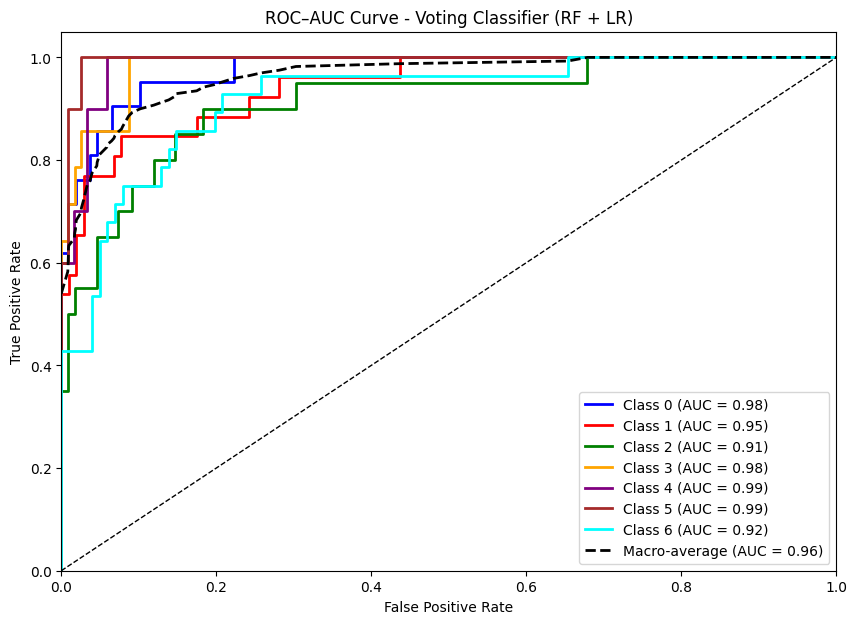

In [47]:
# -----------------------------------------------------
# 📦 Imports
# -----------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

# -----------------------------------------------------
# 🧩 Train-Test Split (adjust if already done)
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

n_classes = len(np.unique(y_train))

# -----------------------------------------------------
# ⚙️ Base Models
# -----------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

# -----------------------------------------------------
# 🧠 Voting Classifier (Soft Voting)
# -----------------------------------------------------
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('lr', lr)],
    voting='soft'
)

# Train the classifier
voting_clf.fit(X_train, y_train)

# -----------------------------------------------------
# 🧾 Predictions
# -----------------------------------------------------
y_pred = voting_clf.predict(X_test)
y_score = voting_clf.predict_proba(X_test)

# -----------------------------------------------------
# 1️⃣ Confusion Matrix
# -----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Voting Classifier (RF + LR)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------------------------------
# 2️⃣ Classification Report
# -----------------------------------------------------
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# -----------------------------------------------------
# 3️⃣ ROC–AUC Curve (Per-class + Macro)
# -----------------------------------------------------
# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot ROC Curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']  # extend if needed

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (AUC = {roc_auc[i]:0.2f})')

plt.plot(fpr["macro"], tpr["macro"], color='black', linestyle='--', lw=2, label=f'Macro-average (AUC = {roc_auc["macro"]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curve - Voting Classifier (RF + LR)')
plt.legend(loc="lower right")
plt.show()
